In [24]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12, 'figure.figsize': (10, 6)})

path1 = 'final_update_60_config1.jsonl'
path2 = 'final_update_60_config2.jsonl'
path3 = 'final_update_60_config3.jsonl'
path4 = 'baseline_config4_update.jsonl'

df1 = pd.read_json(path1, lines=True)
df2 = pd.read_json(path2, lines=True)
df3 = pd.read_json(path3, lines=True)
df4 = pd.read_json(path4, lines=True)

df1['config'] = 0
df2['config'] = 1
df3['config'] = 2
df4['config'] = 3

In [25]:
df_master = pd.concat([df1, df2, df3, df4], axis = 0).reset_index(drop=True)
df_master['is_correct'] = df_master['is_correct'].astype(bool)

is_baseline = df_master['config'] == 0
df_master.loc[is_baseline, 'is_correct'] = df_master.loc[is_baseline, 'phase_1_correct']

# 2. Zero out the flips for the baseline, as it didn't undergo any debate
df_master.loc[is_baseline, ['positive_flip', 'negative_flip']] = 0

/var/folders/lp/2_nhfkdx48b5d_cw8b7r9dx40000gn/T/ipykernel_44035/3579386100.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df_master.loc[is_baseline, ['positive_flip', 'negative_flip']] = 0
/var/folders/lp/2_nhfkdx48b5d_cw8b7r9dx40000gn/T/ipykernel_44035/3579386100.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df_master.loc[is_baseline, ['positive_flip', 'negative_flip']] = 0


In [26]:
df_master.columns

Index(['problem_type', 'problem', 'ground_truth', 'phase_1_answer',
       'final_answer', 'is_correct', 'phase_1_correct', 'positive_flip',
       'negative_flip', 'first_try_success', 'final_code_success',
       'self_healed', 'code_result_raw', 'word_count_phase_1',
       'word_count_code', 'word_count_verdict', 'time_phase_1',
       'time_phase_4_code', 'time_phase_final', 'raw_phase_1', 'raw_critique',
       'raw_code', 'raw_verdict', 'config', 'code_adherence',
       'time_phase_4_5_heal'],
      dtype='object')

/var/folders/lp/2_nhfkdx48b5d_cw8b7r9dx40000gn/T/ipykernel_44035/1756123.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=acc_summary.index, y=acc_summary.values, palette="Blues_d")


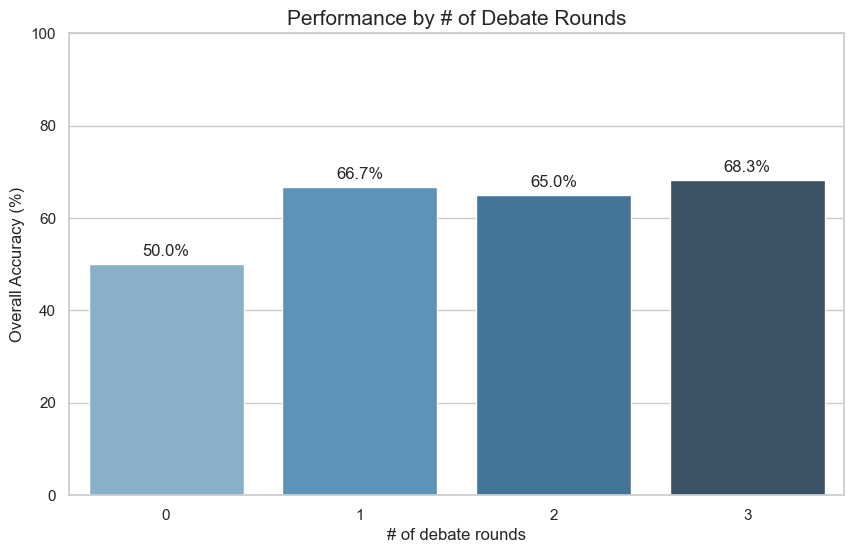

In [27]:
# Calculate Accuracy per Config
acc_summary = df_master.groupby('config')['is_correct'].mean() * 100

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=acc_summary.index, y=acc_summary.values, palette="Blues_d")
plt.title('Performance by # of Debate Rounds', fontsize=15)
plt.ylabel('Overall Accuracy (%)')
plt.xlabel('# of debate rounds')
plt.ylim(0, 100)

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')

plt.show()

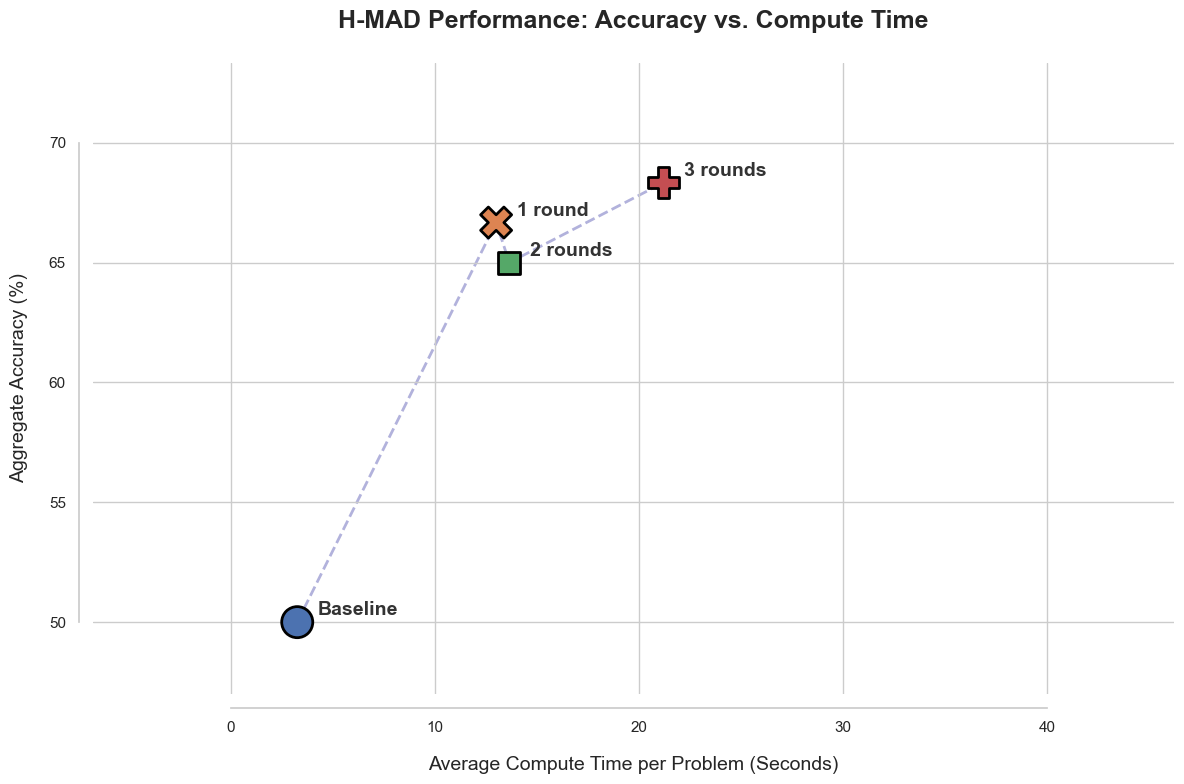

In [33]:
# 1. Define the specific mapping for your research stages
config_labels = {
    0: "Baseline",
    1: "1 round",
    2: "2 rounds",
    3: "3 rounds"
}

# 2. Aesthetics setup
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['font.family'] = 'sans-serif'

# 3. Data Preparation
# Calculate total time if not already in the dataframe
df_master['total_time'] = (df_master['time_phase_1'] + 
                           df_master['time_phase_4_code'] + 
                           df_master['time_phase_final'])

time_acc = df_master.groupby('config').agg({
    'is_correct': 'mean',
    'total_time': 'mean'
}).reset_index()

# Apply your custom labels
time_acc['display_name'] = time_acc['config'].map(config_labels)

# Convert accuracy to percentage for the Y-axis
time_acc['accuracy_pct'] = time_acc['is_correct'] * 100

# 4. Plotting
fig, ax = plt.subplots(figsize=(12, 8))

# Draw the scatter points
# We use a large 's' for high-visibility markers
sns.scatterplot(
    data=time_acc, 
    x='total_time', 
    y='accuracy_pct', 
    hue='display_name', 
    style='display_name',
    s=500, 
    edgecolor='black',
    linewidth=2,
    ax=ax,
    legend=False  # Direct labels are cleaner than a legend box
)

# 5. Direct Annotation (The "Baseline" through "3 rounds" labels)
for i in range(len(time_acc)):
    ax.annotate(
        time_acc['display_name'][i],
        (time_acc['total_time'][i], time_acc['accuracy_pct'][i]),
        xytext=(15, 5),               # Offset the text slightly to the right
        textcoords='offset points',
        fontsize=14,
        fontweight='bold',
        color='#333333'
    )

# 6. The Efficiency Frontier Line
# We draw this behind the points (zorder=0)
plt.plot(
    time_acc['total_time'], 
    time_acc['accuracy_pct'], 
    color='darkblue', 
    linestyle='--', 
    linewidth=2, 
    alpha=0.3, 
    zorder=0
)

# 7. Final Formatting
plt.title('H-MAD Performance: Accuracy vs. Compute Time', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Average Compute Time per Problem (Seconds)', fontsize=14, labelpad=15)
plt.ylabel('Aggregate Accuracy (%)', fontsize=14, labelpad=15)

# Give the plot some "breathing room" on the edges
plt.xlim(time_acc['total_time'].min() - 10, time_acc['total_time'].max() + 25)
plt.ylim(time_acc['accuracy_pct'].min() - 3, time_acc['accuracy_pct'].max() + 5)

sns.despine(offset=10, trim=True)
plt.tight_layout()
plt.show()

In [34]:
time_acc

,config,is_correct,total_time,display_name,accuracy_pct
0,0,0.500000,3.263838,Baseline,50.000000
1,1,0.666667,13.004165,1 round,66.666667
2,2,0.650000,13.651902,2 rounds,65.000000
3,3,0.683333,21.201209,3 rounds,68.333333


In [29]:
# --- 2. ACCURACY BY PROBLEM TYPE TABLE ---
# This identifies exactly which math domains are "agent-friendly"
type_acc = df_master.pivot_table(
    index='problem_type', 
    columns='config', 
    values='is_correct', 
    aggfunc='mean'
) * 100

config_names = {
    0: "Baseline (no debate)",
    1: "Debate (1 round)",
    2: "Debate (2 rounds)",
    3: "Debate (3 rounds)"
}

formatted_table = type_acc.rename(columns=config_names)

# Flatten the headers so it doesn't look messy
formatted_table.columns.name = None 
flat_table = formatted_table.reset_index()
flat_table.rename(columns={'problem_type': 'Problem Domain'}, inplace=True)

# 2. Apply Academic CSS Styling for Visual Studio / Jupyter
styled_table = (
    flat_table.style
    .hide(axis="index")  # Hides the ugly 0, 1, 2 row numbers
    .format(subset=flat_table.columns[1:], formatter="{:.1f}%")  # Formats numbers with %
    .set_caption("Mathematical Accuracy Across Agentic Configurations and Domains")
    .set_table_styles([
        # This CSS mimics the academic \toprule, \midrule, and \bottomrule
        {'selector': 'thead th', 'props': [('border-top', '2px solid black'), 
                                           ('border-bottom', '1px solid black'), 
                                           ('text-align', 'center'),
                                           ('font-weight', 'bold')]},
        {'selector': 'tbody td', 'props': [('text-align', 'center')]},
        {'selector': 'tbody tr:last-child td', 'props': [('border-bottom', '2px solid black')]},
        # Styles the caption
        {'selector': 'caption', 'props': [('caption-side', 'top'), 
                                          ('font-size', '14pt'), 
                                          ('font-weight', 'bold'), 
                                          ('color', 'black'),
                                          ('padding-bottom', '10px')]}
    ])
)

# 3. RENDER IT VISUALLY
display(styled_table)


Problem Domain,Baseline (no debate),Debate (1 round),Debate (2 rounds),Debate (3 rounds)
Algebra,45.0%,75.0%,70.0%,70.0%
Geometry,35.0%,45.0%,50.0%,55.0%
Number Theory,70.0%,80.0%,75.0%,80.0%


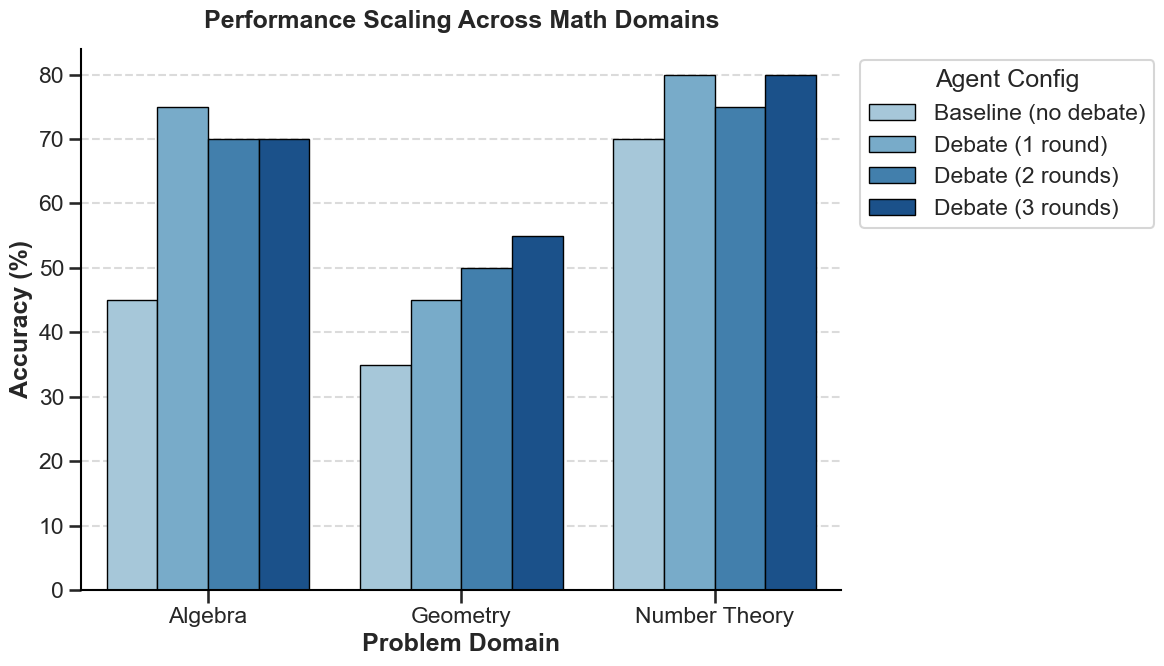

In [30]:
# --- 3. PLOT: PERFORMANCE BY PROBLEM TYPE ---
# Use 'ticks' style instead of 'whitegrid' to give us more control over the axis lines
sns.set_theme(style="ticks", context="talk")
plt.figure(figsize=(12, 7))

# Melt and map the dataframe
type_acc_melted = type_acc.reset_index().melt(id_vars='problem_type', var_name='Config', value_name='Accuracy')
type_acc_melted['Config'] = type_acc_melted['Config'].map(config_names)

# THE PALETTE FIX: Generate 6 shades of blue, but only keep the 4 darkest ones
high_contrast_blues = ['#9ecae1', '#6baed6', '#3182bd', '#08519c']

# Generate the plot
ax = sns.barplot(
    data=type_acc_melted, 
    x='problem_type', 
    y='Accuracy', 
    hue='Config', 
    palette=high_contrast_blues,  # Pass the new list here
    edgecolor='black',
    linewidth=1
)

# --- AXIS FORMATTING FIXES ---

# 1. Make the X and Y axis lines solid, thick, and black
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_linewidth(1.5)
ax.spines['left'].set_color('black')

# 2. Remove the top and right box borders (standard academic formatting)
sns.despine(top=True, right=True)

# 3. Add a subtle horizontal grid behind the bars for readability
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True) # Forces the gridlines to stay behind the bars

# --- LABEL FORMATTING FIXES ---

plt.title('Performance Scaling Across Math Domains', pad=15, fontweight='bold')
plt.ylabel('Accuracy (%)', fontweight='bold')
plt.xlabel('Problem Domain', fontweight='bold')

# Flatten the x-axis labels
plt.xticks(rotation=0) 

# Legend placement
plt.legend(title='Agent Config', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [31]:
# --- 4. ANALYSIS: CHANGING MINDS (FLIPS) ---
# 1. Calculate the base stats
flip_stats = df_master.groupby('config')[['positive_flip', 'negative_flip']].sum()

# 2. Map the configuration names to your updated 0-3 labels
config_names = {
    0: "Baseline (no debate)",
    1: "Debate (1 round)",
    2: "Debate (2 rounds)",
    3: "Debate (3 rounds)"
}
flip_stats.index = flip_stats.index.map(config_names)

# 3. Rename columns for academic clarity
flip_stats = flip_stats.rename(columns={
    'positive_flip': 'Positive Flips (Corrected)',
    'negative_flip': 'Negative Flips (Confused)'
})

# 4. Flatten the table to avoid the "stacked index" LaTeX bug
flip_stats.index.name = None
flat_flip = flip_stats.reset_index()
flat_flip.rename(columns={'index': 'Configuration'}, inplace=True)

# 5. Generate LaTeX using the modern Pandas 2.0+ Styler
latex_table = (
    flat_flip.style
    .hide(axis="index") # Hides the default row numbers
    .format({
        'Positive Flips (Corrected)': "{:.0f}", 
        'Negative Flips (Confused)': "{:.0f}"
    }) # Forces whole numbers instead of decimals
    .to_latex(
        column_format="lcc", # 'l' for left-aligned text, 'c' for centered numbers
        caption="Frequency of Agentic Decision Flips Across Configurations",
        label="tab:flip_analysis",
        hrules=True # Generates \toprule, \midrule, and \bottomrule
    )
)

# Apply the same CSS academic styling we used for the previous table
styled_flip_table = (
    flat_flip.style
    .hide(axis="index")
    .format({
        'Positive Flips (Corrected)': "{:.0f}", 
        'Negative Flips (Confused)': "{:.0f}"
    })
    .set_caption("Table 2: Frequency of Agentic Decision Flips Across Configurations")
    .set_table_styles([
        {'selector': 'thead th', 'props': [('border-top', '2px solid black'), 
                                           ('border-bottom', '1px solid black'), 
                                           ('text-align', 'center'),
                                           ('font-weight', 'bold')]},
        {'selector': 'tbody td', 'props': [('text-align', 'center')]},
        {'selector': 'tbody tr:last-child td', 'props': [('border-bottom', '2px solid black')]},
        {'selector': 'caption', 'props': [('caption-side', 'top'), 
                                          ('font-size', '14pt'), 
                                          ('font-weight', 'bold'), 
                                          ('color', 'black'),
                                          ('padding-bottom', '10px')]}
    ])
)

display(styled_flip_table)

Configuration,Positive Flips (Corrected),Negative Flips (Confused)
Baseline (no debate),0,0
Debate (1 round),13,0
Debate (2 rounds),15,2
Debate (3 rounds),36,1


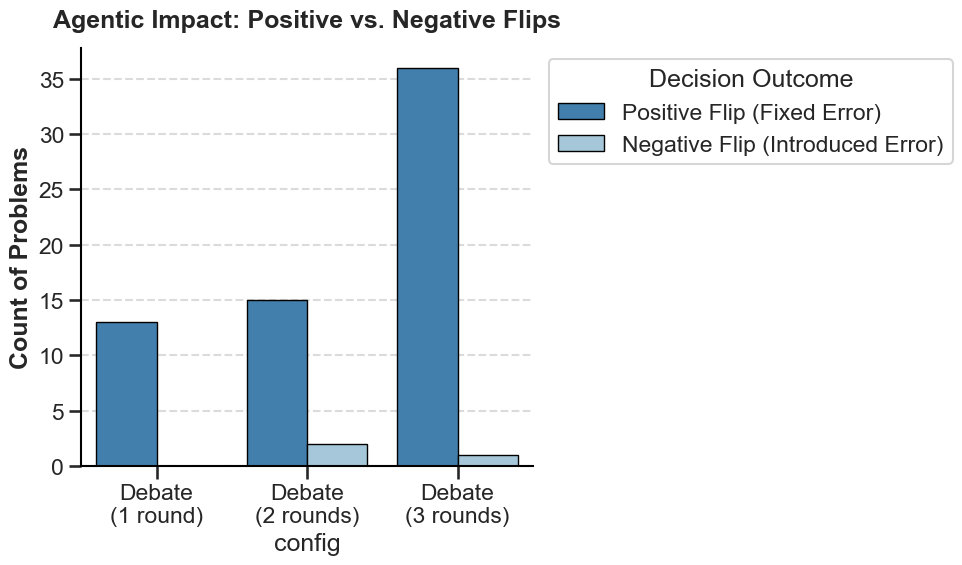

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cleanly recalculate the stats 
df_master.loc[df_master['config'] == 0, ['positive_flip', 'negative_flip']] = 0
flip_stats_clean = df_master.groupby('config')[['positive_flip', 'negative_flip']].sum().reset_index()

# 2. Map the integers to labels
config_names = {
    1: "Debate\n(1 round)",
    2: "Debate\n(2 rounds)",
    3: "Debate\n(3 rounds)"
}
flip_stats_clean['config'] = flip_stats_clean['config'].map(config_names)

# --- THE FIX: Filter out the baseline before melting ---
flip_stats_clean = flip_stats_clean[flip_stats_clean['config'] != "Baseline (no debate)"]

# 3. Melt the data for Seaborn
flip_melted = flip_stats_clean.melt(id_vars='config', var_name='Flip Type', value_name='Count')
flip_melted['Flip Type'] = flip_melted['Flip Type'].map({
    'positive_flip': 'Positive Flip (Fixed Error)',
    'negative_flip': 'Negative Flip (Introduced Error)'
})

# --- VISUALIZATION ---
sns.set_theme(style="ticks", context="talk")
fig, ax = plt.subplots(figsize=(10, 6))

academic_colors = [ '#3182bd','#9ecae1']

# Draw the bars
sns.barplot(
    data=flip_melted, 
    x='config', 
    y='Count', 
    hue='Flip Type', 
    palette=academic_colors,
    edgecolor='black',
    linewidth=1,
    ax=ax
)

# --- AXIS FORMATTING ---
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_linewidth(1.5)
ax.spines['left'].set_color('black')

sns.despine(top=True, right=True)

ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

# --- LABELS ---
plt.title('Agentic Impact: Positive vs. Negative Flips', pad=15, fontweight='bold')
plt.ylabel('Count of Problems', fontweight='bold')

plt.xticks(rotation=0)

plt.legend(
    title='Decision Outcome',
    bbox_to_anchor=(1.01, 1), 
    loc='upper left'
)

plt.tight_layout()
plt.show()